In [1]:
import csv
import json
import re
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Any, List, Tuple

import numpy as np
import soundfile as sf

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import torchaudio
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
MANIFESTS = [
    Path('/home/huy/207177/data/mfa/manifests/learner_dataset/stageI.jsonl'),
    Path('/home/huy/207177/data/mfa/manifests/learner_dataset/stageII.jsonl'),
]
CSV_PATH = Path('/home/huy/207177/data/original_learner_dataset/database_backup/full_assessment.csv')
PRETRAINED = 'facebook/wav2vec2-large-960h'
SR = 16000

CHECKPOINTS = {
    'label1': Path('/home/huy/207177/output/checkpoint/exp_label1_ce/best.pt'),
    'label2': Path('/home/huy/207177/output/checkpoint/exp_label2_ce/best.pt'),
    'label3': Path('/home/huy/207177/output/checkpoint/exp_label3_ce/best.pt'),
}

OUT_ROOT = Path('/home/huy/207177/output/checkpoint/exp_learner_finetune_from_3ckpt')
OUT_ROOT.mkdir(parents=True, exist_ok=True)
TEST_SPK_DIR = Path('/home/huy/207177/output/testing')
TEST_SPK_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_JSON = OUT_ROOT / 'results_pre_post_test.json'

SEED = 1337
BATCH_SIZE = 1
LR_HEAD = 1e-4
LR_FULL = 1e-5
FREEZE_UPDATES = 5000
TOTAL_UPDATES = 30000
WARMUP_UPDATES = 1000
EVAL_EVERY = 1000
MASK_SPEECH_MIN_FRAMES = 5

TEST_SPK_RATIO = 0.20
DEV_SPK_RATIO_IN_TRAIN = 0.05
MIN_DEV_SPK = 10

MODEL_TONE_TO_CSV = {'T1': '1', 'T2': '2', 'T3': '3', 'T4': '4', 'T5': '0'}
TONE_LABELS = ['0', '1', '2', '3', '4']
TONE_TARGET_NAMES = ['T5/neutral', 'T1', 'T2', 'T3', 'T4']

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('CSV:', CSV_PATH, 'exists:', CSV_PATH.exists())
print('Manifests:')
for p in MANIFESTS:
    print(' -', p, 'exists:', p.exists())
for name, p in CHECKPOINTS.items():
    print(name, '->', p, 'exists:', p.exists())
print('Out root:', OUT_ROOT)

Device: cuda
CSV: /home/huy/207177/data/original_learner_dataset/database_backup/full_assessment.csv exists: True
Manifests:
 - /home/huy/207177/data/mfa/manifests/learner_dataset/stageI.jsonl exists: True
 - /home/huy/207177/data/mfa/manifests/learner_dataset/stageII.jsonl exists: True
label1 -> /home/huy/207177/output/checkpoint/exp_label1_ce/best.pt exists: True
label2 -> /home/huy/207177/output/checkpoint/exp_label2_ce/best.pt exists: True
label3 -> /home/huy/207177/output/checkpoint/exp_label3_ce/best.pt exists: True
Out root: /home/huy/207177/output/checkpoint/exp_learner_finetune_from_3ckpt


In [3]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def read_manifest(path: Path) -> List[Dict[str, Any]]:
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(x) for x in f if x.strip()]

def read_manifests(paths: List[Path]) -> List[Dict[str, Any]]:
    items: List[Dict[str, Any]] = []
    for p in paths:
        if not p.exists():
            print('Warning: missing manifest ->', p)
            continue
        part = read_manifest(p)
        print(f'Loaded {len(part)} items from {p}')
        items.extend(part)
    print('Total loaded items:', len(items))
    return items

def load_csv_tone_table(csv_path: Path):
    tone_map: Dict[str, Dict[str, Dict[int, str]]] = {}
    with csv_path.open('r', encoding='utf-8-sig', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            spk = str(row['id']).strip()
            d_a = {}
            d_q = {}
            for n in range(0, 11):
                v = row.get(f'a{n}t', None)
                if v is None or str(v).strip() == '' or str(v).upper() == 'NULL':
                    d_a[n] = None
                else:
                    d_a[n] = str(int(float(v)))
            for n in range(1, 19):
                v = row.get(f'q{n}t', None)
                if v is None or str(v).strip() == '' or str(v).upper() == 'NULL':
                    d_q[n] = None
                else:
                    d_q[n] = str(int(float(v)))
            tone_map[spk] = {'a': d_a, 'q': d_q}
    return tone_map

def get_speaker_id(ex: Dict[str, Any]) -> str:
    utt = str(ex.get('utt', ''))
    return utt.split('__')[0] if '__' in utt else utt

def tone_to_id(tone_csv: str, label2id: Dict[str, int]) -> int:
    lab = 'T5' if str(tone_csv) == '0' else f'T{str(tone_csv)}'
    if lab not in label2id:
        raise KeyError(f'{lab} not found in label2id keys: {sorted(label2id.keys())}')
    return label2id[lab]

def csv_tone_from_utt(utt: str, tone_map: Dict[str, Dict[str, Dict[int, str]]]):
    m_a = re.match(r'^(.+)__a(\d+)$', utt)
    if m_a:
        spk = m_a.group(1)
        idx = int(m_a.group(2))
        if spk in tone_map:
            return tone_map[spk]['a'].get(idx)
        return None

    m_q = re.match(r'^(.+)__q(\d+)$', utt)
    if m_q:
        spk = m_q.group(1)
        idx = int(m_q.group(2))
        if spk in tone_map:
            return tone_map[spk]['q'].get(idx)
        return None

    return None

def split_by_speaker(items: List[Dict[str, Any]], test_spk_txt: Path):
    spk2items: Dict[str, List[Dict[str, Any]]] = {}
    for ex in items:
        spk = get_speaker_id(ex)
        spk2items.setdefault(spk, []).append(ex)

    speakers = sorted(spk2items.keys())
    random.shuffle(speakers)

    n_spk = len(speakers)
    test_n = max(1, int(TEST_SPK_RATIO * n_spk))
    test_speakers = speakers[:test_n]
    train_all = speakers[test_n:]

    dev_n = max(MIN_DEV_SPK, int(DEV_SPK_RATIO_IN_TRAIN * len(train_all)))
    dev_n = min(dev_n, max(1, len(train_all) - 1))
    dev_speakers = train_all[:dev_n]
    train_speakers = train_all[dev_n:]

    train_items = [x for spk in train_speakers for x in spk2items[spk]]
    dev_items = [x for spk in dev_speakers for x in spk2items[spk]]
    test_items = [x for spk in test_speakers for x in spk2items[spk]]

    test_spk_txt.parent.mkdir(parents=True, exist_ok=True)
    test_spk_txt.write_text('\n'.join(sorted(test_speakers)) + '\n', encoding='utf-8')

    print('Speakers total:', n_spk)
    print(
        'Train speakers:', len(train_speakers),
        'Dev speakers:', len(dev_speakers),
        'Test speakers:', len(test_speakers),
    )
    print('Train/Dev/Test items:', len(train_items), len(dev_items), len(test_items))
    print('Test speaker list:', test_spk_txt)
    return train_items, dev_items, test_items

class ToneDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]

class FrameToneModel(nn.Module):
    def __init__(self, pretrained: str, num_labels: int):
        super().__init__()
        self.w2v = Wav2Vec2Model.from_pretrained(pretrained)
        self.w2v.freeze_feature_encoder()

        n_layers = self.w2v.config.num_hidden_layers + 1
        self.layer_weights = nn.Parameter(torch.zeros(n_layers))
        self.proj = nn.Linear(self.w2v.config.hidden_size, num_labels)

    def freeze_encoder(self):
        for p in self.w2v.parameters():
            p.requires_grad = False

    def unfreeze_transformer(self):
        for n, p in self.w2v.named_parameters():
            if not n.startswith('feature_extractor'):
                p.requires_grad = True

    def forward(self, input_values, attention_mask=None):
        out = self.w2v(
            input_values=input_values,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        stack = torch.stack(out.hidden_states, dim=0)
        weights = torch.softmax(self.layer_weights, dim=0).view(-1, 1, 1, 1)
        fused = (stack * weights).sum(dim=0)
        return self.proj(fused)

def nearest_resample(mask_25ms: torch.Tensor, n_frames: int):
    L = mask_25ms.numel()
    if L == 0 or n_frames <= 0:
        return torch.zeros(n_frames, dtype=torch.bool)
    idx = torch.linspace(0, L - 1, steps=n_frames)
    idx = torch.round(idx).long().clamp(0, L - 1)
    return mask_25ms[idx].bool()

def majority_tone_from_logits(logits_f: torch.Tensor, mask_f: torch.Tensor, id2label: Dict[int, str]):
    pred_ids = logits_f.argmax(dim=-1)[mask_f].detach().cpu().tolist()
    mapped = []
    for pid in pred_ids:
        lbl = id2label.get(int(pid), None)
        if lbl in MODEL_TONE_TO_CSV:
            mapped.append(MODEL_TONE_TO_CSV[lbl])
    if len(mapped) == 0:
        return None
    counts: Dict[str, int] = {}
    for t in mapped:
        counts[t] = counts.get(t, 0) + 1
    return max(counts, key=counts.get)

@dataclass
class Collator:
    feature_extractor: Wav2Vec2FeatureExtractor

    def _load_audio(self, path: str):
        audio, sr = sf.read(path, dtype='float32')
        if audio.ndim == 2:
            audio = audio.mean(axis=1)
        if sr != SR:
            audio = torchaudio.functional.resample(torch.from_numpy(audio), sr, SR).numpy()
        return audio.astype(np.float32)

    def _load_mask(self, path: str):
        s = Path(path).read_text(encoding='utf-8').strip().split()
        if not s:
            return torch.zeros(0, dtype=torch.bool)
        return torch.tensor([int(x) for x in s], dtype=torch.bool)

    def __call__(self, batch):
        wavs, masks, tones, utts = [], [], [], []
        for ex in batch:
            wavs.append(self._load_audio(ex['audio']))
            masks.append(self._load_mask(ex['mask']))
            tones.append(str(ex['tone']))
            utts.append(str(ex['utt']))

        inputs = self.feature_extractor(
            wavs,
            sampling_rate=SR,
            return_tensors='pt',
            padding=True,
            return_attention_mask=True,
        )
        return {
            'input_values': inputs['input_values'],
            'attention_mask': inputs.get('attention_mask'),
            'masks_25ms': masks,
            'tones': tones,
            'utts': utts,
        }

In [4]:
@torch.no_grad()
def evaluate_utterance_acc(
    model: nn.Module,
    loader: DataLoader,
    device: str,
    id2label: Dict[int, str],
    tone_map: Dict[str, Dict[str, Dict[int, str]]],
):
    model.eval()
    correct, total = 0, 0
    skipped_no_csv = 0
    skipped_no_pred = 0

    for batch in loader:
        x = batch['input_values'].to(device)
        m = batch['attention_mask']
        if m is not None:
            m = m.to(device)

        logits = model(x, m)
        B, F, _ = logits.shape

        for b in range(B):
            utt = batch['utts'][b]
            true_tone = csv_tone_from_utt(utt, tone_map)
            if true_tone is None:
                skipped_no_csv += 1
                continue

            mask_f = nearest_resample(batch['masks_25ms'][b], F).to(device)
            if mask_f.sum() < MASK_SPEECH_MIN_FRAMES:
                mask_f = torch.ones(F, dtype=torch.bool, device=device)

            pred_tone = majority_tone_from_logits(logits[b], mask_f, id2label)
            if pred_tone is None:
                skipped_no_pred += 1
                continue

            correct += int(pred_tone == true_tone)
            total += 1

    model.train()
    return correct / max(1, total), {
        'compared': total,
        'skipped_no_csv': skipped_no_csv,
        'skipped_no_pred': skipped_no_pred,
    }

@torch.no_grad()
def evaluate_predictions(
    model: nn.Module,
    loader: DataLoader,
    device: str,
    id2label: Dict[int, str],
    tone_map: Dict[str, Dict[str, Dict[int, str]]],
) -> Tuple[List[str], List[str], Dict[str, int]]:
    model.eval()
    y_true: List[str] = []
    y_pred: List[str] = []
    skipped_no_csv = 0
    skipped_no_pred = 0

    for batch in loader:
        x = batch['input_values'].to(device)
        m = batch['attention_mask']
        if m is not None:
            m = m.to(device)

        logits = model(x, m)
        B, F, _ = logits.shape

        for b in range(B):
            utt = batch['utts'][b]
            true_tone = csv_tone_from_utt(utt, tone_map)
            if true_tone is None:
                skipped_no_csv += 1
                continue

            mask_f = nearest_resample(batch['masks_25ms'][b], F).to(device)
            if mask_f.sum() < MASK_SPEECH_MIN_FRAMES:
                mask_f = torch.ones(F, dtype=torch.bool, device=device)

            pred_tone = majority_tone_from_logits(logits[b], mask_f, id2label)
            if pred_tone is None:
                skipped_no_pred += 1
                continue

            y_true.append(true_tone)
            y_pred.append(pred_tone)

    model.train()
    return y_true, y_pred, {
        'compared': len(y_true),
        'skipped_no_csv': skipped_no_csv,
        'skipped_no_pred': skipped_no_pred,
    }

def report_and_cm(y_true: List[str], y_pred: List[str]):
    if not y_true:
        return {}, [[0] * len(TONE_LABELS) for _ in TONE_LABELS]

    rep_dict = classification_report(
        y_true, y_pred,
        labels=TONE_LABELS,
        target_names=TONE_TARGET_NAMES,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    print(classification_report(
        y_true, y_pred,
        labels=TONE_LABELS,
        target_names=TONE_TARGET_NAMES,
        digits=4,
        zero_division=0,
    ))
    cm = confusion_matrix(y_true, y_pred, labels=TONE_LABELS)
    print('Confusion matrix:'.format(TONE_LABELS))
    print(cm)
    return rep_dict, cm.tolist()

In [5]:
def finetune_one_checkpoint(
    ckpt_name: str,
    ckpt_path: Path,
    train_items: List[Dict[str, Any]],
    dev_items: List[Dict[str, Any]],
    test_items: List[Dict[str, Any]],
    tone_map: Dict[str, Dict[str, Dict[int, str]]],
):
    print('\n' + '=' * 60)
    print(f'== {ckpt_name}')
    print(f'== Loading checkpoint: {ckpt_path}')
    print('=' * 60)

    out_dir = OUT_ROOT / ckpt_name
    out_dir.mkdir(parents=True, exist_ok=True)

    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(PRETRAINED)
    ckpt = torch.load(ckpt_path, map_location='cpu')
    label2id = ckpt['label2id']
    id2label = {v: k for k, v in label2id.items()}
    print('Loaded label2id with', len(label2id), 'labels:', sorted(label2id.keys()))

    train_loader = DataLoader(
        ToneDataset(train_items),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        collate_fn=Collator(feature_extractor),
    )
    dev_loader = DataLoader(
        ToneDataset(dev_items),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=Collator(feature_extractor),
    )
    test_loader = DataLoader(
        ToneDataset(test_items),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=Collator(feature_extractor),
    )

    model = FrameToneModel(PRETRAINED, num_labels=len(label2id)).to(DEVICE)
    missing, unexpected = model.load_state_dict(ckpt['model'], strict=False)
    if missing:
        print('  load_state_dict missing keys:', missing)
    if unexpected:
        print('  load_state_dict unexpected keys:', unexpected)
    model.w2v.config.apply_spec_augment = False
    model.w2v.config.mask_time_prob = 0.0
    model.w2v.config.mask_feature_prob = 0.0

    print('\nPre-finetune evaluation on test split:')
    pre_y_true, pre_y_pred, pre_info = evaluate_predictions(model, test_loader, DEVICE, id2label, tone_map)
    pre_test_acc = (
        sum(int(t == p) for t, p in zip(pre_y_true, pre_y_pred)) / len(pre_y_true)
        if pre_y_true else 0.0
    )
    print(
        f"pre_test_acc={pre_test_acc:.4f} | compared={pre_info['compared']} | "
        f"no_csv={pre_info['skipped_no_csv']} | no_pred={pre_info['skipped_no_pred']}"
    )
    pre_report, pre_cm = report_and_cm(pre_y_true, pre_y_pred)

    model.freeze_encoder()
    optim = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR_HEAD)
    sched = get_linear_schedule_with_warmup(optim, WARMUP_UPDATES, TOTAL_UPDATES)
    loss_fn = nn.CrossEntropyLoss()

    curves = {
        'exp_tag': f'finetune_{ckpt_name}',
        'pretrained': PRETRAINED,
        'checkpoint_path': str(ckpt_path),
        'freeze_updates': int(FREEZE_UPDATES),
        'eval_every': int(EVAL_EVERY),
        'total_updates': int(TOTAL_UPDATES),
        'train_step': [],
        'train_loss': [],
        'dev_step': [],
        'dev_acc': [],
    }

    best_dev = 0.0
    step = 0
    pbar = tqdm(total=TOTAL_UPDATES, desc=f'finetune-{ckpt_name}')

    while step < TOTAL_UPDATES:
        for batch in train_loader:
            x = batch['input_values'].to(DEVICE)
            m = batch['attention_mask']
            if m is not None:
                m = m.to(DEVICE)

            logits = model(x, m)
            B, F, _ = logits.shape

            loss_sum = 0.0
            valid_n = 0
            for b in range(B):
                utt = batch['utts'][b]
                tone_csv = csv_tone_from_utt(utt, tone_map)
                if tone_csv is None:
                    tone_csv = batch['tones'][b]
                if tone_csv is None or str(tone_csv).strip() == '':
                    continue
                try:
                    gold_id = tone_to_id(tone_csv, label2id)
                except KeyError:
                    continue

                mask_f = nearest_resample(batch['masks_25ms'][b], F).to(DEVICE)
                if mask_f.sum() < MASK_SPEECH_MIN_FRAMES:
                    mask_f = torch.ones(F, dtype=torch.bool, device=DEVICE)

                y = torch.full((F,), gold_id, device=DEVICE)
                if mask_f.sum() > 0:
                    loss_sum += loss_fn(logits[b][mask_f], y[mask_f])
                    valid_n += 1

            if valid_n == 0:
                continue

            loss = loss_sum / valid_n
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optim.step()
            sched.step()
            optim.zero_grad(set_to_none=True)

            step += 1
            curves['train_step'].append(int(step))
            curves['train_loss'].append(float(loss.item()))
            pbar.update(1)
            pbar.set_postfix(loss=float(loss.item()))

            if step == FREEZE_UPDATES:
                print('\nUnfreezing wav2vec2 transformer')
                model.unfreeze_transformer()
                optim = torch.optim.AdamW(
                    [p for p in model.parameters() if p.requires_grad],
                    lr=LR_FULL,
                )
                sched = get_linear_schedule_with_warmup(
                    optim,
                    WARMUP_UPDATES,
                    max(1, TOTAL_UPDATES - FREEZE_UPDATES),
                )

            if step % EVAL_EVERY == 0:
                dev_acc, dev_info = evaluate_utterance_acc(
                    model, dev_loader, DEVICE, id2label, tone_map,
                )
                curves['dev_step'].append(int(step))
                curves['dev_acc'].append(float(dev_acc))
                print(
                    f"\nstep {step}: dev_acc={dev_acc:.4f}, "
                    f"compared={dev_info['compared']}, no_csv={dev_info['skipped_no_csv']}, "
                    f"no_pred={dev_info['skipped_no_pred']}"
                )
                if dev_acc > best_dev:
                    best_dev = dev_acc
                    torch.save(
                        {'model': model.state_dict(), 'label2id': label2id},
                        out_dir / 'best.pt',
                    )
                    print('saved best.pt ->', best_dev)

            if step >= TOTAL_UPDATES:
                break

    pbar.close()
    torch.save({'model': model.state_dict(), 'label2id': label2id}, out_dir / 'last.pt')
    print('Saved last.pt')

    with (out_dir / 'training_curves.json').open('w', encoding='utf-8') as f:
        json.dump(curves, f, ensure_ascii=False, indent=2)
    print('Saved training_curves.json')

    print('\nPost-finetune evaluation on test split:')
    post_y_true, post_y_pred, post_info = evaluate_predictions(model, test_loader, DEVICE, id2label, tone_map)
    post_test_acc = (
        sum(int(t == p) for t, p in zip(post_y_true, post_y_pred)) / len(post_y_true)
        if post_y_true else 0.0
    )
    print(
        f"post_test_acc={post_test_acc:.4f} | compared={post_info['compared']} | "
        f"no_csv={post_info['skipped_no_csv']} | no_pred={post_info['skipped_no_pred']}"
    )
    post_report, post_cm = report_and_cm(post_y_true, post_y_pred)

    summary = {
        'checkpoint': ckpt_name,
        'checkpoint_path': str(ckpt_path),
        'pretrained': PRETRAINED,
        'pre_test_acc': float(pre_test_acc),
        'post_test_acc': float(post_test_acc),
        'delta': float(post_test_acc - pre_test_acc),
        'best_dev_acc': float(best_dev),
        'pre_eval_info': pre_info,
        'post_eval_info': post_info,
        'pre_classification_report': pre_report,
        'post_classification_report': post_report,
        'pre_confusion_matrix': pre_cm,
        'post_confusion_matrix': post_cm,
        'tone_labels': TONE_LABELS,
        'tone_target_names': TONE_TARGET_NAMES,
        'train_items': len(train_items),
        'dev_items': len(dev_items),
        'test_items': len(test_items),
        'save_dir': str(out_dir),
        'training_curves': str((out_dir / 'training_curves.json').resolve()),
    }
    with (out_dir / 'summary.json').open('w', encoding='utf-8') as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    print('Saved summary.json')

    return summary, curves

In [6]:
set_seed(SEED)
items = read_manifests(MANIFESTS)
if len(items) == 0:
    raise RuntimeError('No items loaded from MANIFESTS. Check manifest paths.')

tone_map = load_csv_tone_table(CSV_PATH)
test_spk_txt = TEST_SPK_DIR / 'test_speakers_finetune_from_3ckpt.txt'
train_items, dev_items, test_items = split_by_speaker(items, test_spk_txt)

all_summaries = []
all_curves: Dict[str, Dict[str, Any]] = {}
for ckpt_name, ckpt_path in CHECKPOINTS.items():
    if not ckpt_path.exists():
        print(f'Skip {ckpt_name}: missing {ckpt_path}')
        continue
    summary, curves = finetune_one_checkpoint(
        ckpt_name, ckpt_path, train_items, dev_items, test_items, tone_map,
    )
    all_summaries.append(summary)
    all_curves[ckpt_name] = curves

with RESULTS_JSON.open('w', encoding='utf-8') as f:
    json.dump(all_summaries, f, ensure_ascii=False, indent=2)

print('\nSaved aggregate summary:', RESULTS_JSON)
for s in all_summaries:
    macro_f1_pre = s['pre_classification_report'].get('macro avg', {}).get('f1-score', 0.0)
    macro_f1_post = s['post_classification_report'].get('macro avg', {}).get('f1-score', 0.0)
    print(
        s['checkpoint'],
        '| pre acc:', f"{s['pre_test_acc']:.4f}",
        '| post acc:', f"{s['post_test_acc']:.4f}",
        '| delta:', f"{s['delta']:+.4f}",
        '| pre macro-F1:', f"{macro_f1_pre:.4f}",
        '| post macro-F1:', f"{macro_f1_post:.4f}",
    )

Loaded 6623 items from /home/huy/207177/data/mfa/manifests/learner_dataset/stageI.jsonl
Loaded 4700 items from /home/huy/207177/data/mfa/manifests/learner_dataset/stageII.jsonl
Total loaded items: 11323
Speakers total: 678
Train speakers: 516 Dev speakers: 27 Test speakers: 135
Train/Dev/Test items: 8577 464 2282
Test speaker list: /home/huy/207177/output/testing/test_speakers_finetune_from_3ckpt.txt

== label1
== Loading checkpoint: /home/huy/207177/output/checkpoint/exp_label1_ce/best.pt


/home/huy/.conda/envs/tone_ce/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded label2id with 6 labels: ['T1', 'T2', 'T3', 'T4', 'T5', 'sil']


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-large-960h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Pre-finetune evaluation on test split:


...

finetune-label3:  97%|█████████▋| 29004/30000 [21:34<05:54,  2.81it/s, loss=0.0022]  


step 29000: dev_acc=0.7392, compared=464, no_csv=0, no_pred=0


finetune-label3: 100%|██████████| 30000/30000 [22:25<00:00, 22.29it/s, loss=0.00169] 


step 30000: dev_acc=0.7457, compared=464, no_csv=0, no_pred=0


Saved last.pt
Saved training_curves.json

Post-finetune evaluation on test split:
post_test_acc=0.7625 | compared=2282 | no_csv=0 | no_pred=0
              precision    recall  f1-score   support

  T5/neutral     0.5695    0.5121    0.5393       248
          T1     0.7887    0.8299    0.8087       670
          T2     0.8198    0.7336    0.7743       732
          T3     0.4309    0.6240    0.5098       125
          T4     0.8533    0.8718    0.8624       507

    accuracy                         0.7625      2282
   macro avg     0.6924    0.7143    0.6989      2282
weighted avg     0.7696    0.7625    0.7640      2282

Confusion matrix:
[[127  22  42  36  21]
 [ 25 556  56   6  27]
 [ 45  85 537  49  16]
 [ 11   9  15  78  12]
 [ 15  33   5  12 442]]
Saved summary.json

Saved aggregate summary: /home/huy/207177/output/checkpoint/exp_learner_finetune_from_3ckpt/results_pre_post_test.json
label1 | pre acc: 0.5315 | post acc: 0.7656 | delta: +0.2340 | pre macro-F1: 0.3904 | post macro

Wrote /home/huy/207177/output/checkpoint/exp_learner_finetune_from_3ckpt/label1/training_curves.png


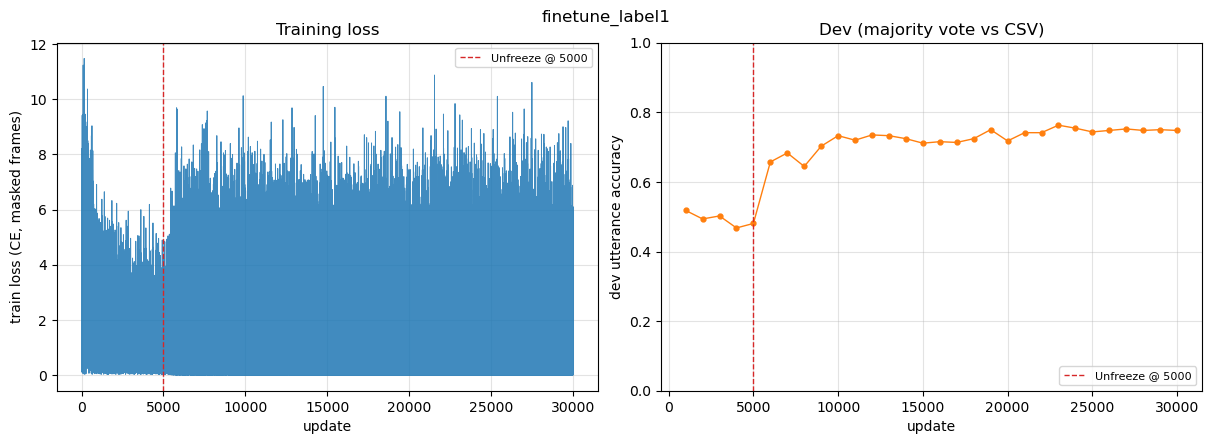

Wrote /home/huy/207177/output/checkpoint/exp_learner_finetune_from_3ckpt/label2/training_curves.png


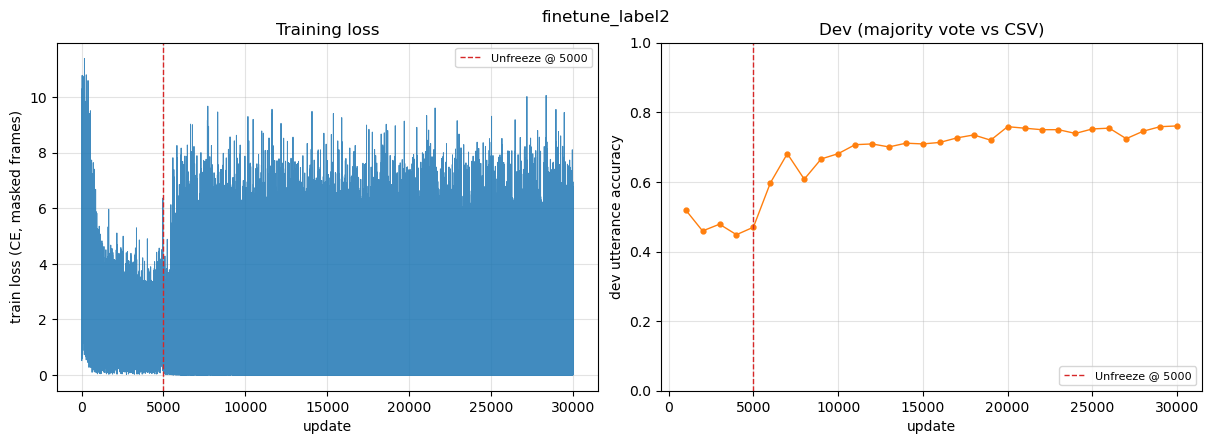

Wrote /home/huy/207177/output/checkpoint/exp_learner_finetune_from_3ckpt/label3/training_curves.png


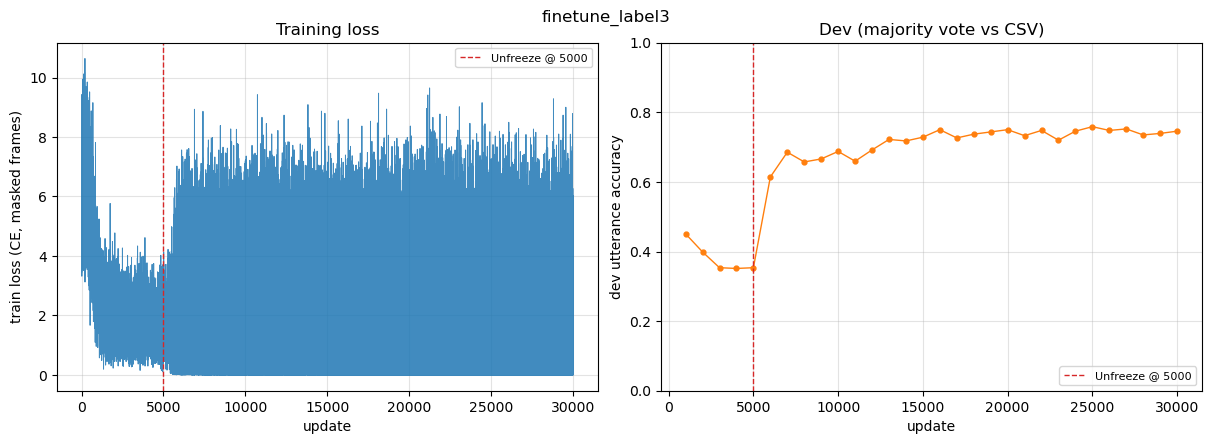

In [11]:
import matplotlib.pyplot as plt

def plot_w2v_training_curves(curves: dict = None, save_dir: Path = None, save_fig: bool = True) -> None:
    if curves is None and save_dir is not None:
        p = save_dir / 'training_curves.json'
        if not p.is_file():
            print('No curves file:', p)
            return
        with p.open('r', encoding='utf-8') as f:
            curves = json.load(f)
    if curves is None:
        print('No curves provided.')
        return

    t_step = curves.get('train_step', [])
    t_loss = curves.get('train_loss', [])
    d_step = curves.get('dev_step', [])
    d_acc = curves.get('dev_acc', [])
    fu = curves.get('freeze_updates', FREEZE_UPDATES)
    tag = curves.get('exp_tag', 'finetune')

    if not t_step and not d_step:
        print('No curve data in dict.')
        return

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
    if t_step and t_loss:
        ax0.plot(t_step, t_loss, color='C0', lw=0.7, alpha=0.85)
    ax0.axvline(fu, color='C3', ls='--', lw=1.0, label=f'Unfreeze @ {fu}')
    ax0.set_xlabel('update')
    ax0.set_ylabel('train loss (CE, masked frames)')
    ax0.set_title('Training loss')
    ax0.grid(True, alpha=0.35)
    ax0.legend(loc='upper right', fontsize=8)

    if d_step and d_acc:
        ax1.plot(d_step, d_acc, color='C1', marker='o', ms=3.5, lw=1.0)
    ax1.axvline(fu, color='C3', ls='--', lw=1.0, label=f'Unfreeze @ {fu}')
    ax1.set_xlabel('update')
    ax1.set_ylabel('dev utterance accuracy')
    ax1.set_title('Dev (majority vote vs CSV)')
    ax1.set_ylim(0, 1.0)
    ax1.grid(True, alpha=0.35)
    ax1.legend(loc='lower right', fontsize=8)

    fig.suptitle(tag, y=1.02)
    if save_fig and save_dir is not None:
        out = save_dir / 'training_curves.png'
        fig.savefig(out, dpi=150, bbox_inches='tight')
        print('Wrote', out)
    plt.show()

_all_curves = globals().get('all_curves', {})
for ckpt_name in CHECKPOINTS:
    out_dir = OUT_ROOT / ckpt_name
    plot_w2v_training_curves(curves=_all_curves.get(ckpt_name), save_dir=out_dir, save_fig=True)

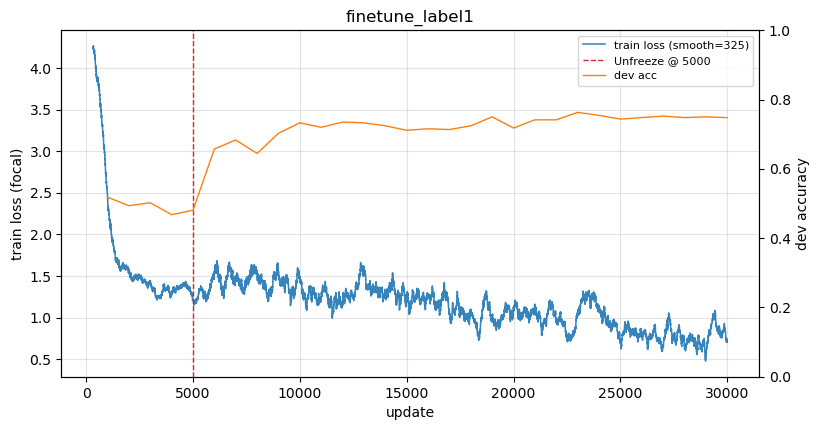

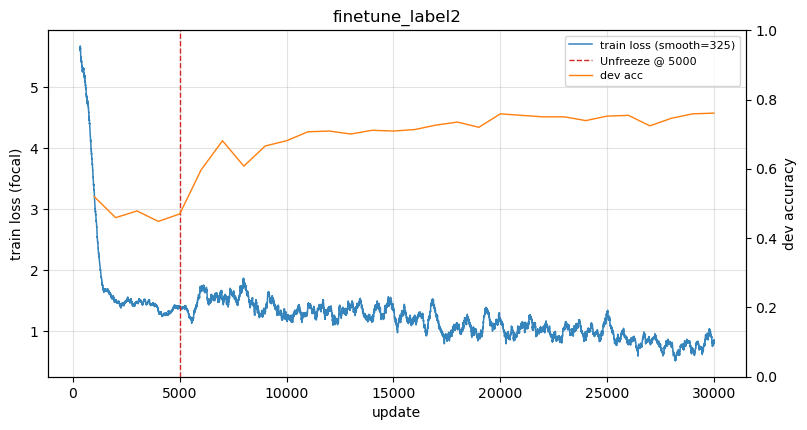

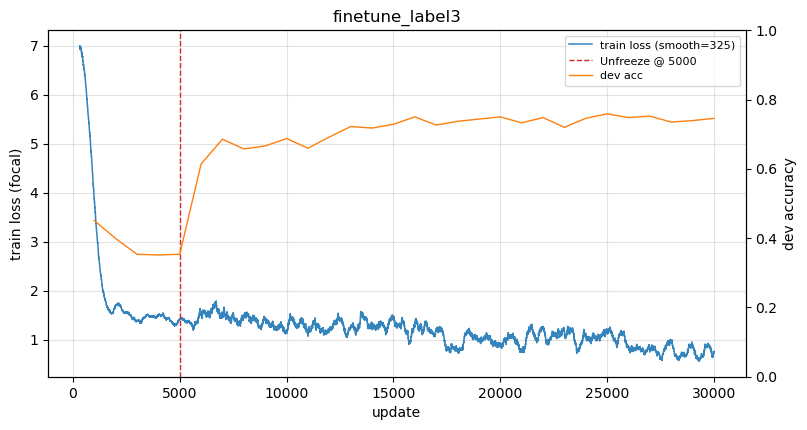

In [10]:

import matplotlib.pyplot as plt
import numpy as np

def _smooth_curve(values, window: int = 25):
    if len(values) < 3 or window <= 1:
        return values
    window = min(window, len(values))
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


def plot_loss_and_accuracy(curves: dict = None, smooth_window: int = 25, save_dir: Path = None, exp_tag: str = None) -> None:
    if curves is None:
        p = save_dir / "training_curves.json"
        if not p.is_file():
            print("No in-memory history and no file:", p)
            return
        with p.open("r", encoding="utf-8") as f:
            curves = json.load(f)

    t_step = curves.get("train_step", [])
    t_loss = curves.get("train_loss", [])
    d_step = curves.get("dev_step", [])
    d_acc = curves.get("dev_acc", [])
    fu = curves.get("freeze_updates", FREEZE_UPDATES)
    tag = curves.get("exp_tag", exp_tag or "aishell")

    if not t_step and not d_step:
        print("No curve data in dict.")
        return

    fig, ax1 = plt.subplots(figsize=(9, 4.5))
    if t_step and t_loss:
        t_loss_sm = _smooth_curve(t_loss, window=smooth_window)
        t_step_sm = t_step[len(t_step) - len(t_loss_sm):]
        ax1.plot(t_step_sm, t_loss_sm, color="C0", lw=1.1, alpha=0.9, label=f"train loss (smooth={smooth_window})")
        
    ax1.set_xlabel("update")
    ax1.set_ylabel("train loss (focal)")
    ax1.grid(True, alpha=0.35)
    ax1.axvline(fu, color="C3", ls="--", lw=1.0, label=f"Unfreeze @ {fu}")

    ax2 = ax1.twinx()
    if d_step and d_acc:
        ax2.plot(d_step, d_acc, color="C1", ms=3.2, lw=1.0, label="dev acc")
    ax2.set_ylabel("dev accuracy")
    ax2.set_ylim(0, 1.0)

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper right", fontsize=8)
    ax1.set_title(tag)
    plt.show()

_all_curves = globals().get('all_curves', {})
for ckpt_name in CHECKPOINTS:
    out_dir = OUT_ROOT / ckpt_name
    plot_loss_and_accuracy(curves=_all_curves.get(ckpt_name), smooth_window=325, save_dir=out_dir, exp_tag=f'aishell_{ckpt_name}')
    